# Advection-Diffusion: Observation Scale Sweep

This notebook explores how observation scale choices affect MESS estimation results. It sweeps over different values for `obs_scale`, which controls the observed slice indices, and compares posterior samples for the skew-symmetric matrix $A$.

Key goals:
- Generate data for multiple observation scales.
- Run MESS with $M=10$ and uniform distance (no angular distance).
- Save chains to disk for reproducibility.
- Visualize posterior histograms for selected components of $A$ across configurations.

## Imports

In [1]:
# Core imports and repo-local modules.
import os
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

repo_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
src_path = os.path.join(repo_root, 'src')
if src_path not in sys.path:
    sys.path.insert(0, src_path)

from multiproposal.data.advection_diffusion import generate_advection_diffusion_data
from multiproposal.problems.advection_diffusion import AdvectionDiffusionToy, ij_to_k, skew_from_params
from multiproposal.algorithms.mess import mess_step

## Global Configuration
These settings control dimension, seeds, and default hyperparameters. Later you can edit the hyperparameters section to sweep them as well.

In [2]:
# Seeds
seed_data = 0
seed_mcmc = 0

# Dimensions
dim = 4
num_params = dim * (dim - 1) // 2

# Hyperparameters (edit later to explore sensitivity)
kappa = 0.01  # Diffusion coefficient
sigma = 0.5  # Observation noise standard deviation
alpha = 1.5 # 2  # Decay rate for i*j
gamma = 2.5 # 4  # Decay rate for |i-j|
tau2 = 1.0  # Prior scale
a_mode = "nearest_neighbor"
use_prior_A = True  # If True, sample A from the prior

# MCMC configuration
n_iters = 300000
burn_in = 2000
thin = 1
mess_M = 5

# Output locations
exp_dir = Path(repo_root) / "estimations" / "AD_toy_obs_scale" / f"dim{dim}_seed{seed_data}"
exp_dir.mkdir(parents=True, exist_ok=True)

In [3]:
# Observation configs (edit to explore different choices)
# For d=11
obs_configs = [
    # {'highest_freq': 7, 'bandwidth': 5},
    {'highest_freq': 7, 'bandwidth': 3},
    {'highest_freq': 7, 'bandwidth': 1},
    {'highest_freq': 0, 'bandwidth': 1},
    {'highest_freq': 5, 'bandwidth': 5},
    # {'highest_freq': dim - 1, 'bandwidth': 3},
    {'highest_freq': dim - 1, 'bandwidth': dim - 1},
]
# For d=4
obs_configs = [
    {'highest_freq': 0, 'bandwidth': 1}, # large scale only
    {'highest_freq': 1, 'bandwidth': 2}, # 2 largest modes
    {'highest_freq': 2, 'bandwidth': 2}, # central modes
    {'highest_freq': 3, 'bandwidth': 1}, # HF mode only
    {'highest_freq': 3, 'bandwidth': 2}, # 2 highest modes
    {'highest_freq': 3, 'bandwidth': 4}, # all modes
]

## Helper Functions
Utilities for building the problem, running MESS, saving results, and plotting histograms.

In [4]:
def get_obs_indices(highest_freq, bandwidth, dim_value):
    bandwidth = max(1, min(bandwidth, dim_value))
    highest_freq = max(0, min(highest_freq, dim_value - 1))
    start = max(0, highest_freq - bandwidth + 1)
    return np.arange(start, highest_freq + 1, dtype=int)


def build_problem_for_obs_config(highest_freq, bandwidth, use_prior_A=False):
    obs_indices = get_obs_indices(highest_freq, bandwidth, dim)
    a_mode_local = "prior" if use_prior_A else a_mode

    data = generate_advection_diffusion_data(
        dim=dim,
        kappa=kappa,
        sigma=sigma,
        obs_indices=obs_indices,
        alpha=alpha,
        gamma=gamma,
        tau2=tau2,
        a_mode=a_mode_local,
        seed=seed_data,
    )
    problem = AdvectionDiffusionToy(
        dim=dim,
        kappa=kappa,
        sigma=sigma,
        y=data['y'],
        obs_indices=obs_indices,
        g=data['g'],
        prior_diag=data['prior_diag'],
    )
    return data, problem, obs_indices


def run_mess_chain(problem, x0, n_steps, rng, M=10):
    chain = np.zeros((n_steps + 1, x0.shape[0]))
    chain[0] = x0.copy()
    x = x0.copy()
    for t in range(n_steps):
        x, _, _ = mess_step(x, problem, rng, M=M, use_lp=False)
        chain[t + 1] = x
    return chain


def save_chain(save_path, chain, metadata):
    np.savez_compressed(
        save_path,
        chain=chain,
        metadata=metadata,
    )


def get_component_labels(dim_value, comps):
    labels = []
    for k in comps:
        # Convert k back to (i, j) for readability.
        count = 0
        found = False
        for i in range(dim_value):
            for j in range(i + 1, dim_value):
                if count == k:
                    labels.append(f"a_{{{i}{j}}}")
                    found = True
                    break
                count += 1
            if found:
                break
        if not found:
            labels.append(f"param_{k}")
    return labels


def plot_posterior_histograms(chains_by_label, obs_indices_by_label, a_true, comps, bins=30):
    n_comp = len(comps)
    n_cols = 2
    n_rows = int(np.ceil(n_comp / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 3 * n_rows), sharex=False)
    axes = np.array(axes).reshape(-1)
    labels = get_component_labels(dim, comps)
    for idx, comp in enumerate(comps):
        ax = axes[idx]
        for label, chain in chains_by_label.items():
            post = chain[burn_in::thin]
            ax.hist(post[:, comp], bins=bins, density=True, alpha=0.35, label=label)
            mean_val = float(np.mean(post[:, comp]))
            ax.axvline(mean_val, color='black', linestyle=':', linewidth=1.0)
        ax.axvline(a_true[comp], color='red', linestyle='--', linewidth=1.3)
        ax.set_title(labels[idx])
        ax.grid(alpha=0.3)
    for ax in axes[n_comp:]:
        ax.axis('off')
    obs_summary = ' | '.join([f'{label}: {obs.tolist()}' for label, obs in obs_indices_by_label.items()])
    fig.suptitle(f'Observed indices: {obs_summary}', fontsize=10)
    axes[0].legend(loc='upper right')
    plt.tight_layout(rect=[0, 0, 1, 0.93])
    return fig


def plot_histograms_by_config(chains_by_label, obs_indices_by_label, a_true, comps, bins=30):
    labels = get_component_labels(dim, comps)
    figs = []
    for label, chain in chains_by_label.items():
        n_comp = len(comps)
        n_cols = 2
        n_rows = int(np.ceil(n_comp / n_cols))
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 3 * n_rows), sharex=False)
        axes = np.array(axes).reshape(-1)
        post = chain[burn_in::thin]
        for idx, comp in enumerate(comps):
            ax = axes[idx]
            ax.hist(post[:, comp], bins=bins, density=True, alpha=0.5, color='steelblue')
            mean_val = float(np.mean(post[:, comp]))
            ax.axvline(mean_val, color='black', linestyle=':', linewidth=1.0)
            ax.axvline(a_true[comp], color='red', linestyle='--', linewidth=1.3)
            ax.set_title(labels[idx])
            ax.grid(alpha=0.3)
        for ax in axes[n_comp:]:
            ax.axis('off')
        obs_indices = obs_indices_by_label.get(label)
        if obs_indices is not None:
            title = f"{label} | obs_indices={obs_indices.tolist()}"
        else:
            title = label
        fig.suptitle(title, fontsize=10)
        plt.tight_layout(rect=[0, 0, 1, 0.93])
        figs.append(fig)
    return figs

## Run Observation-Scale Sweep
This runs MESS for each `obs_scale` choice, saves the chain, and stores results in memory for plotting.

In [5]:
obs_configs = [
    {'highest_freq': 0, 'bandwidth': 1}, # large scale only
    {'highest_freq': 1, 'bandwidth': 2}, # 2 largest modes
    {'highest_freq': 2, 'bandwidth': 2}, # central modes
    {'highest_freq': 3, 'bandwidth': 1}, # HF mode only
    {'highest_freq': 3, 'bandwidth': 2}, # 2 highest modes
    {'highest_freq': 3, 'bandwidth': 4}, # all modes
]
obs_configs

[{'highest_freq': 0, 'bandwidth': 1},
 {'highest_freq': 1, 'bandwidth': 2},
 {'highest_freq': 2, 'bandwidth': 2},
 {'highest_freq': 3, 'bandwidth': 1},
 {'highest_freq': 3, 'bandwidth': 2},
 {'highest_freq': 3, 'bandwidth': 4}]

In [6]:
chains_by_label = {}
true_by_label = {}
obs_indices_by_label = {}

for config in obs_configs:
    highest_freq = config['highest_freq']
    bandwidth = config['bandwidth']
    data, problem, obs_indices = build_problem_for_obs_config(
        highest_freq, bandwidth, use_prior_A=use_prior_A
    )
    rng = np.random.default_rng(seed_mcmc)
    save_path = exp_dir / f"mess_{mess_M}_N{n_iters}_chain_hf{highest_freq}_bw{bandwidth}.npz"
    if save_path.exists():
        print(f"Chain already exists at {save_path}, skipping MCMC run.")
        chain = np.load(save_path)['chain']
    else:
        print(f"Running MESS chain for highest_freq={highest_freq}, bandwidth={bandwidth} with obs_indices={obs_indices}...")
        chain = run_mess_chain(problem, data['a_init'], n_iters, rng, M=mess_M)
        save_chain(save_path, chain, metadata)
        print(f"Saved chain to {save_path}")

    label = f"hf={highest_freq}, bw={bandwidth}"
    chains_by_label[label] = chain
    true_by_label[label] = data['a_true']
    obs_indices_by_label[label] = obs_indices

    metadata = {
        'dim': dim,
        'highest_freq': highest_freq,
        'bandwidth': bandwidth,
        'obs_indices': obs_indices.tolist(),
        'seed_data': seed_data,
        'seed_mcmc': seed_mcmc,
        'n_iters': n_iters,
        'burn_in': burn_in,
        'thin': thin,
        'mess_M': mess_M,
        'hyperparameters': {
            'kappa': kappa,
            'sigma': sigma,
            'alpha': alpha,
            'gamma': gamma,
            'tau2': tau2,
            'a_mode': 'prior' if use_prior_A else a_mode,
            'use_prior_A': use_prior_A,
        },
    }
    

print("Finished sweep.")

a_true: [ 0.03143256 -0.01467832  0.04002642  0.01150469 -0.02852185  0.02358029], prior_diag: [0.0625     0.01234568 0.00390625 0.01202813 0.00283506 0.00425259], a_true.shape: (6,), prior_diag.shape: (6,)
Chain already exists at /Users/guillers/Documents/GitHub/multiproposal/estimations/AD_toy_obs_scale/dim4_seed0/mess_5_N300000_chain_hf0_bw1.npz, skipping MCMC run.
a_true: [ 0.03143256 -0.01467832  0.04002642  0.01150469 -0.02852185  0.02358029], prior_diag: [0.0625     0.01234568 0.00390625 0.01202813 0.00283506 0.00425259], a_true.shape: (6,), prior_diag.shape: (6,)
Chain already exists at /Users/guillers/Documents/GitHub/multiproposal/estimations/AD_toy_obs_scale/dim4_seed0/mess_5_N300000_chain_hf1_bw2.npz, skipping MCMC run.
a_true: [ 0.03143256 -0.01467832  0.04002642  0.01150469 -0.02852185  0.02358029], prior_diag: [0.0625     0.01234568 0.00390625 0.01202813 0.00283506 0.00425259], a_true.shape: (6,), prior_diag.shape: (6,)
Chain already exists at /Users/guillers/Documents/G

## Posterior Histograms for Selected Components
Compare posterior samples across observation scales for chosen $A$ components.

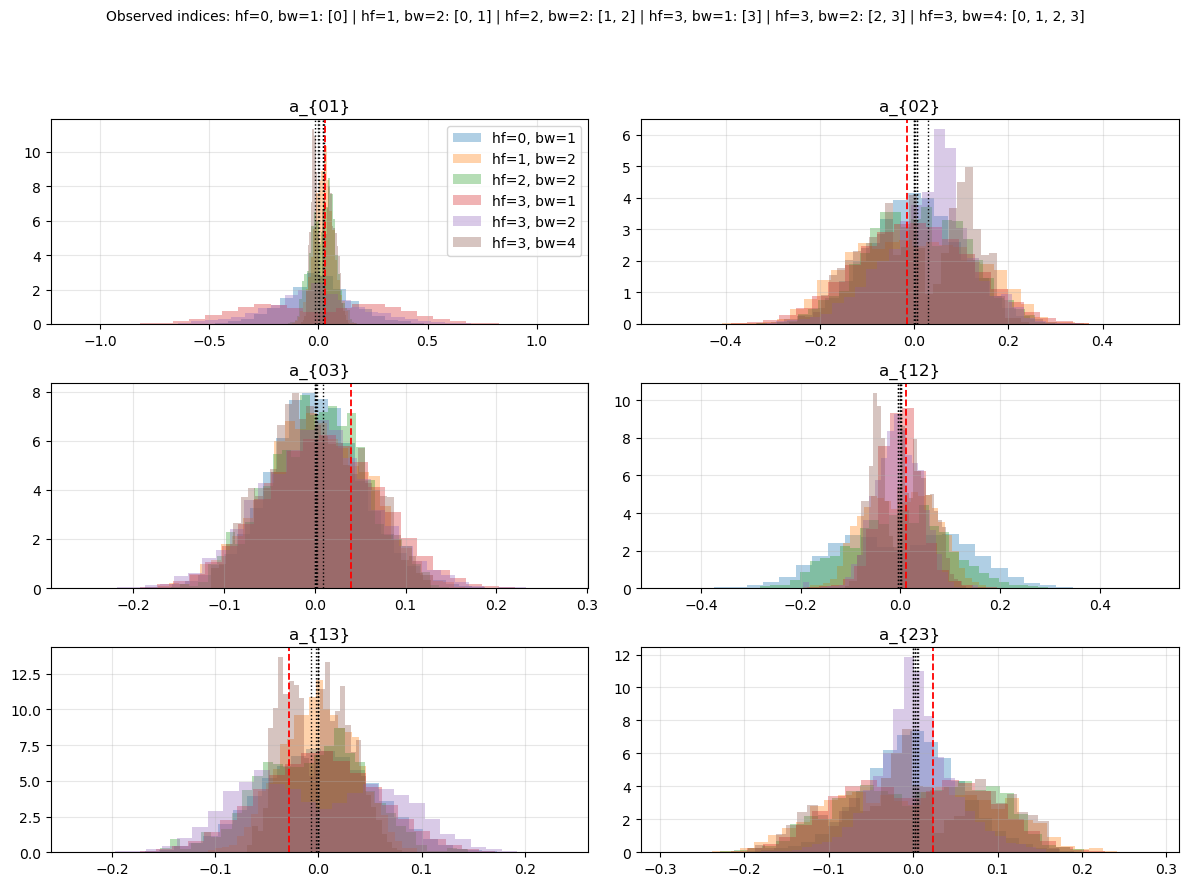

In [9]:
# Select components to visualize (indices in the vectorized upper triangle).
comps = [0, 1, 2, 10, 15, 25, 30, ij_to_k(0, dim - 1, dim), num_params - 2, num_params - 1]
comps = np.arange(num_params)  

# Use the first configuration's truth as reference in plots.
first_label = list(true_by_label.keys())[0]
a_true = true_by_label[first_label]

fig = plot_posterior_histograms(chains_by_label, obs_indices_by_label, a_true, comps, bins=30)
fig.savefig(exp_dir / "posterior_histograms_obs_scale.png", dpi=300)
plt.show()

In [10]:
def plot_hist_by_config(chains_by_label, obs_indices_by_label, a_true, comps, bins=30):
    labels = get_component_labels(dim, comps)
    figs = []
    for label, chain in chains_by_label.items():
        n_comp = len(comps)
        n_cols = 2
        n_rows = int(np.ceil(n_comp / n_cols))
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 3 * n_rows), sharex=True)
        axes = np.array(axes).reshape(-1)
        post = chain[burn_in::thin]
        for idx, comp in enumerate(comps):
            ax = axes[idx]
            ax.hist(post[:, comp], bins=bins, density=True, alpha=0.5, color='steelblue')
            mean_val = float(np.mean(post[:, comp]))
            ax.axvline(mean_val, color='black', linestyle=':', linewidth=1.0)
            ax.axvline(a_true[comp], color='red', linestyle='--', linewidth=1.3)
            ax.set_title(labels[idx])
            ax.grid(alpha=0.3)
        for ax in axes[n_comp:]:
            ax.axis('off')
        # bias_config = np.mean(post[:, :], axis=0) - a_true
        # plt.plot(np.mean(post[:, :], axis=0), label=f'postmean_{label}')
        obs_indices = obs_indices_by_label.get(label)
        if obs_indices is not None:
            title = f"{label} | obs_indices={obs_indices.tolist()}"
        else:
            title = label
        fig.suptitle(title, fontsize=10)
        figs.append(fig)
    # plt.plot(a_true, marker='o', label=f'true', color='black')
    # plt.legend(loc='upper right')
    # plt.tight_layout(rect=[0, 0, 1, 0.93])
    return figs

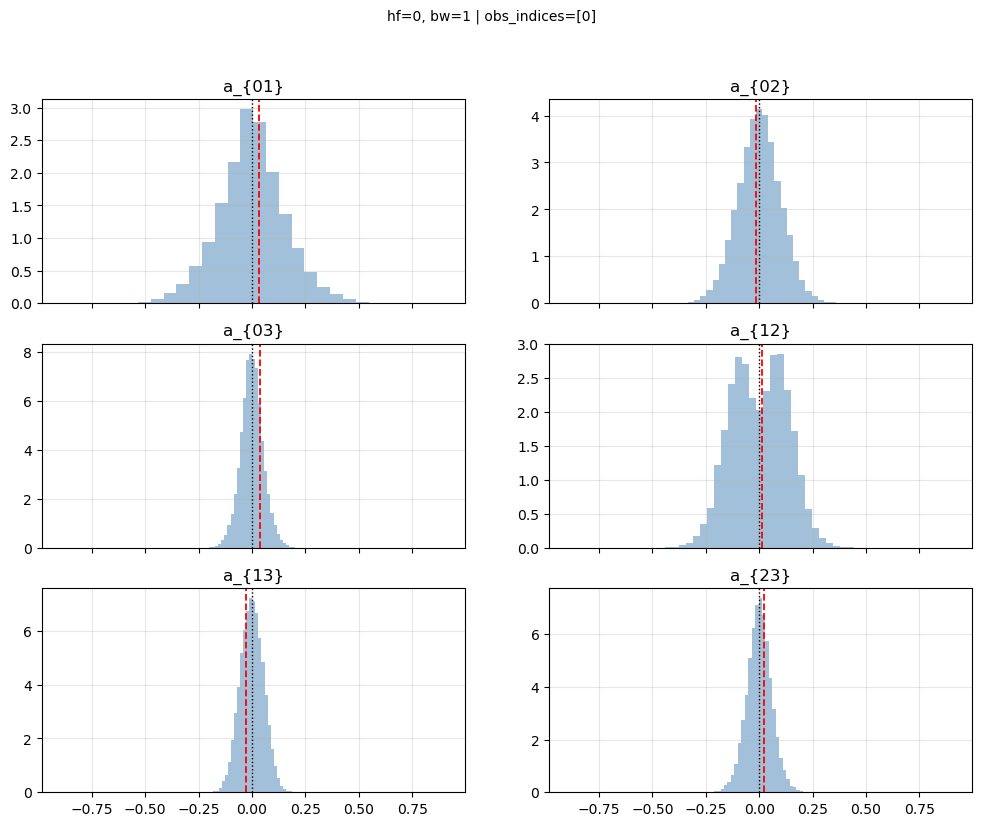

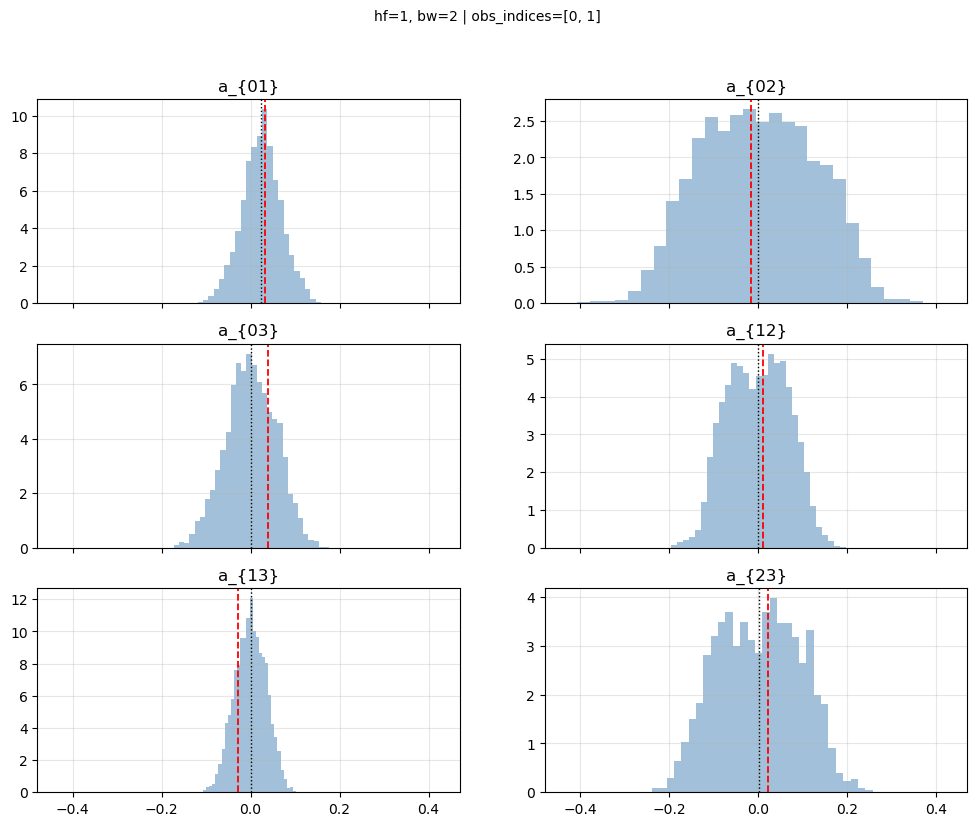

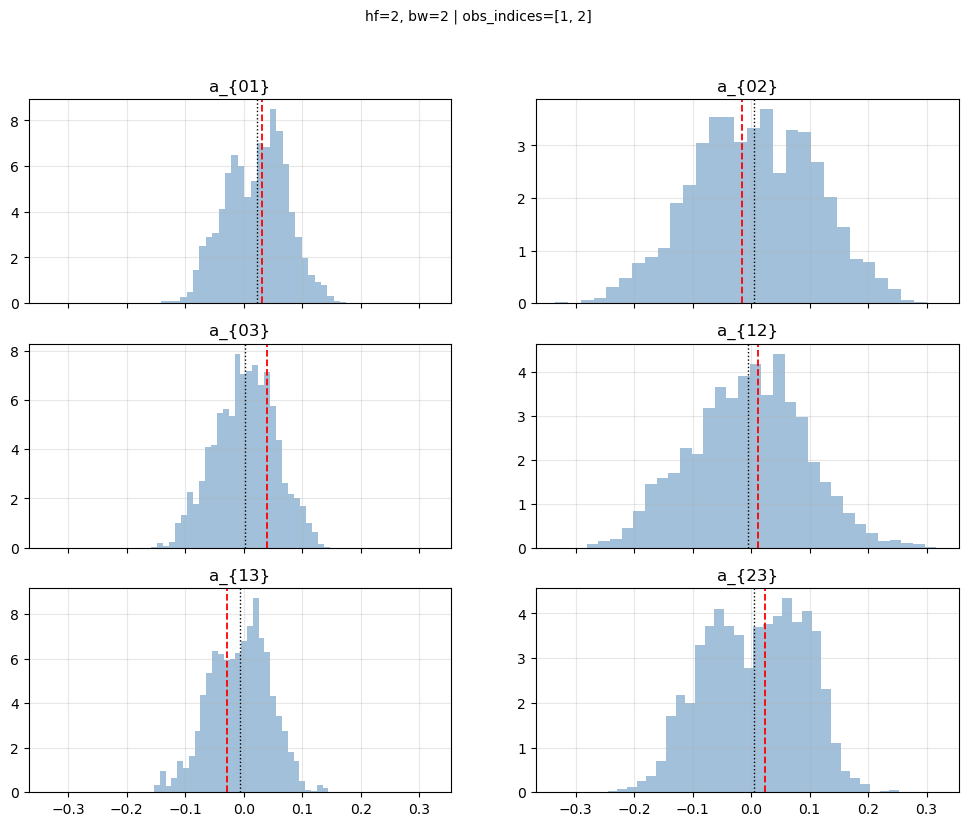

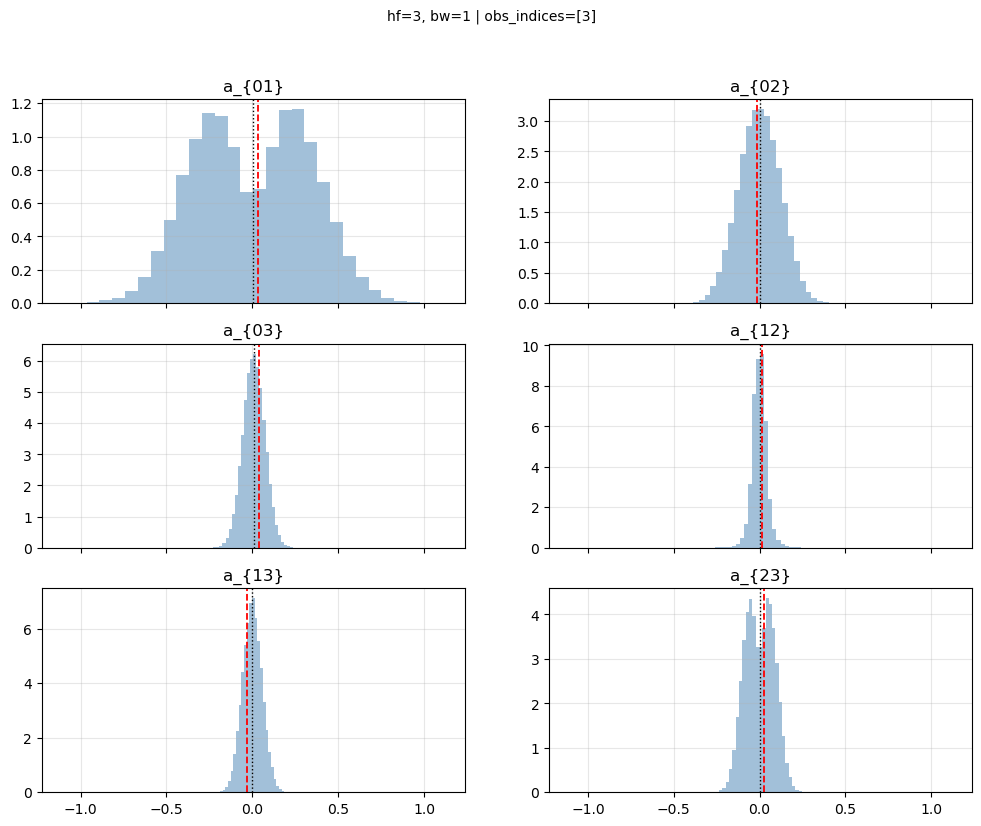

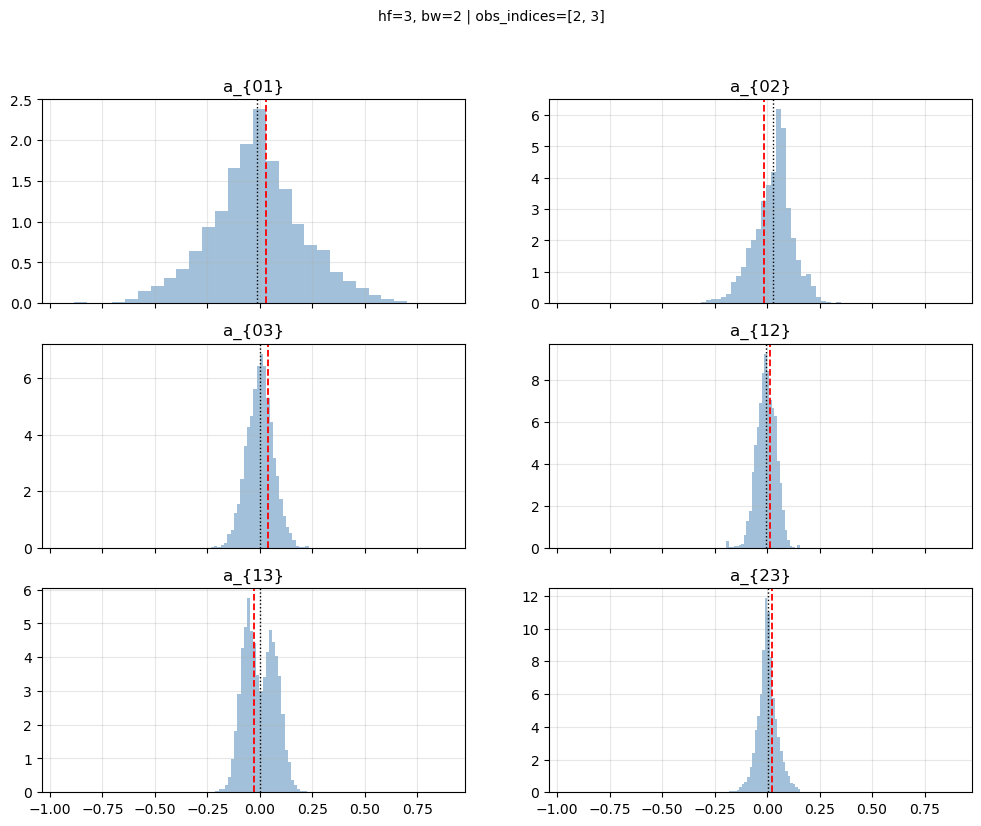

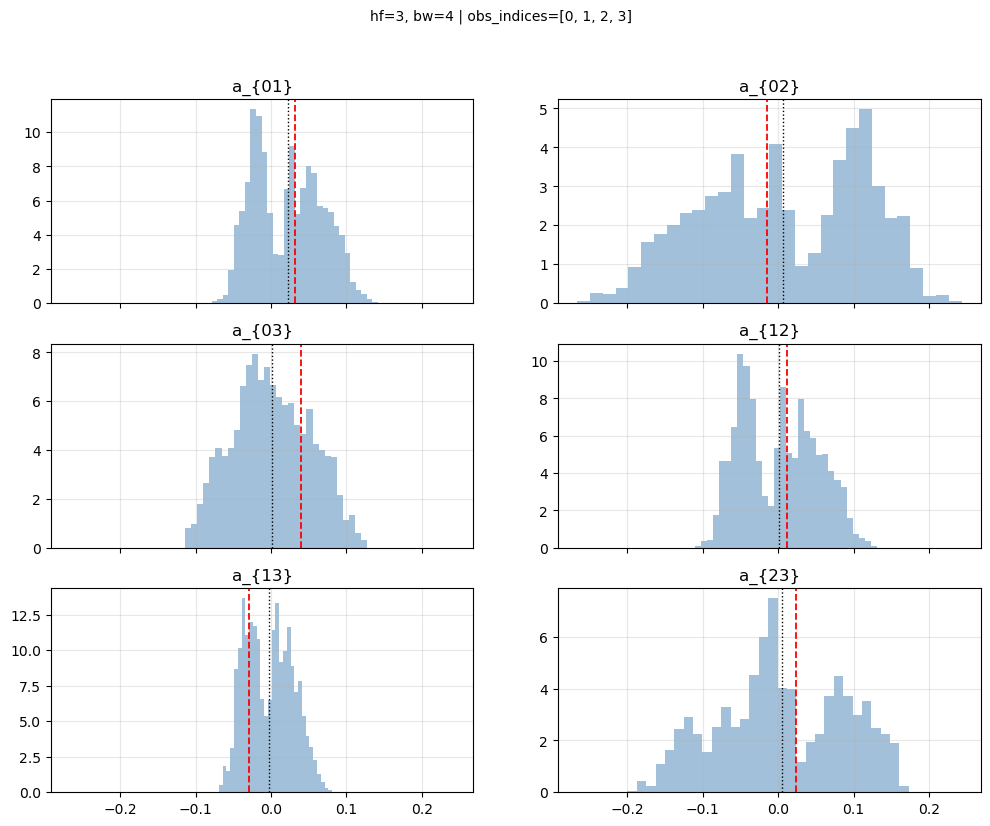

In [11]:
# Separate histograms per observation config (no overlays).
comps = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
comps = [0, 1, 10, 11, 19, 20, 28, 29, 37, 38, 46, 47]
comps = np.arange(num_params)
figs_by_config = plot_hist_by_config(
    chains_by_label, obs_indices_by_label, a_true, comps
 )
plt.show()

In [12]:
def plot_bias_image_by_config(chains_by_label, obs_indices_by_label, a_true, comps, bins=30):
    # labels = get_component_labels(dim, comps)
    figs = []
    for label, chain in chains_by_label.items():
        # n_comp = len(comps)
        # n_cols = 2
        # n_rows = int(np.ceil(n_comp / n_cols))
        # fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 3 * n_rows), sharex=False)
        # axes = np.array(axes).reshape(-1)
        post = chain[burn_in::thin]
        # for idx, comp in enumerate(comps):
        #     ax = axes[idx]
        #     ax.hist(post[:, comp], bins=bins, density=True, alpha=0.5, color='steelblue')
        #     mean_val = float(np.mean(post[:, comp]))
        #     ax.axvline(mean_val, color='black', linestyle=':', linewidth=1.0)
        #     ax.axvline(a_true[comp], color='red', linestyle='--', linewidth=1.3)
        #     ax.set_title(labels[idx])
        #     ax.grid(alpha=0.3)
        # for ax in axes[n_comp:]:
        #     ax.axis('off')
        bias_config = np.mean(post[:, :], axis=0) - a_true
        plt.plot(np.mean(post[:, :], axis=0), label=f'postmean_{label}')
        obs_indices = obs_indices_by_label.get(label)
        if obs_indices is not None:
            title = f"{label} | obs_indices={obs_indices.tolist()}"
        else:
            title = label
        fig.suptitle(title, fontsize=10)
        figs.append(fig)
    plt.plot(a_true, marker='o', label=f'true', color='black')
    plt.legend(loc='upper right')
    plt.tight_layout(rect=[0, 0, 1, 0.93])
    return figs

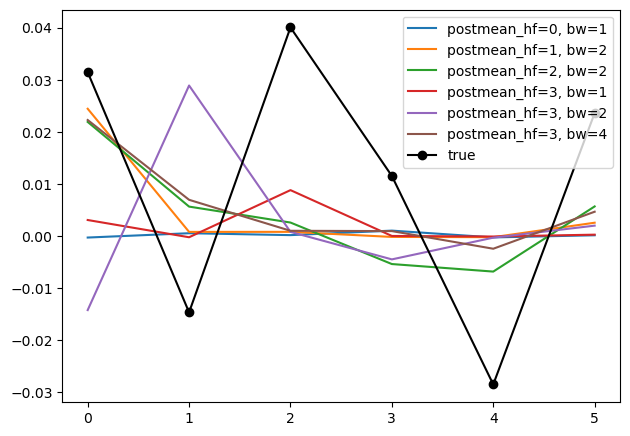

In [13]:
# Separate histograms per observation config (no overlays).
comps = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
comps = [0, 1, 10, 11, 19, 20, 28, 29, 37, 38, 46, 47]
comps = np.arange(num_params)
figs_by_config = plot_bias_image_by_config(
    chains_by_label, obs_indices_by_label, a_true, comps
 )
plt.show()

## Optional: Inspect Observed Indices
This cell prints the observation indices for each configuration so you can confirm the slice definitions.

In [14]:
for label, obs_indices in obs_indices_by_label.items():
    print(label, "obs_indices=", obs_indices.tolist())

hf=0, bw=1 obs_indices= [0]
hf=1, bw=2 obs_indices= [0, 1]
hf=2, bw=2 obs_indices= [1, 2]
hf=3, bw=1 obs_indices= [3]
hf=3, bw=2 obs_indices= [2, 3]
hf=3, bw=4 obs_indices= [0, 1, 2, 3]


## Experiments with hyperpars

a_true: [ 0.72157388 -0.49183796  0.05226236 -0.11589549 -0.05334523 -0.03111877], prior_diag: [0.125      0.03703704 0.015625   0.04166667 0.01388889 0.02083333], a_true.shape: (6,), prior_diag.shape: (6,)
A_true=
[[ 0.          0.72157388 -0.49183796  0.05226236]
 [-0.72157388  0.         -0.11589549 -0.05334523]
 [ 0.49183796  0.11589549  0.         -0.03111877]
 [-0.05226236  0.05334523  0.03111877  0.        ]]
a_true: [ 0.46788277 -0.24752625  0.02197361 -0.06550623 -0.02374919 -0.01612909], prior_diag: [0.05255603 0.00938069 0.00276214 0.01331131 0.00275279 0.00559672], a_true.shape: (6,), prior_diag.shape: (6,)
A_true=
[[ 0.          0.46788277 -0.24752625  0.02197361]
 [-0.46788277  0.         -0.06550623 -0.02374919]
 [ 0.24752625  0.06550623  0.         -0.01612909]
 [-0.02197361  0.02374919  0.01612909  0.        ]]
a_true: [ 0.2496483  -0.09145977  0.00625583 -0.02943906 -0.00752835 -0.00650452], prior_diag: [0.01496255 0.00128071 0.00022388 0.00268846 0.00027662 0.0009102

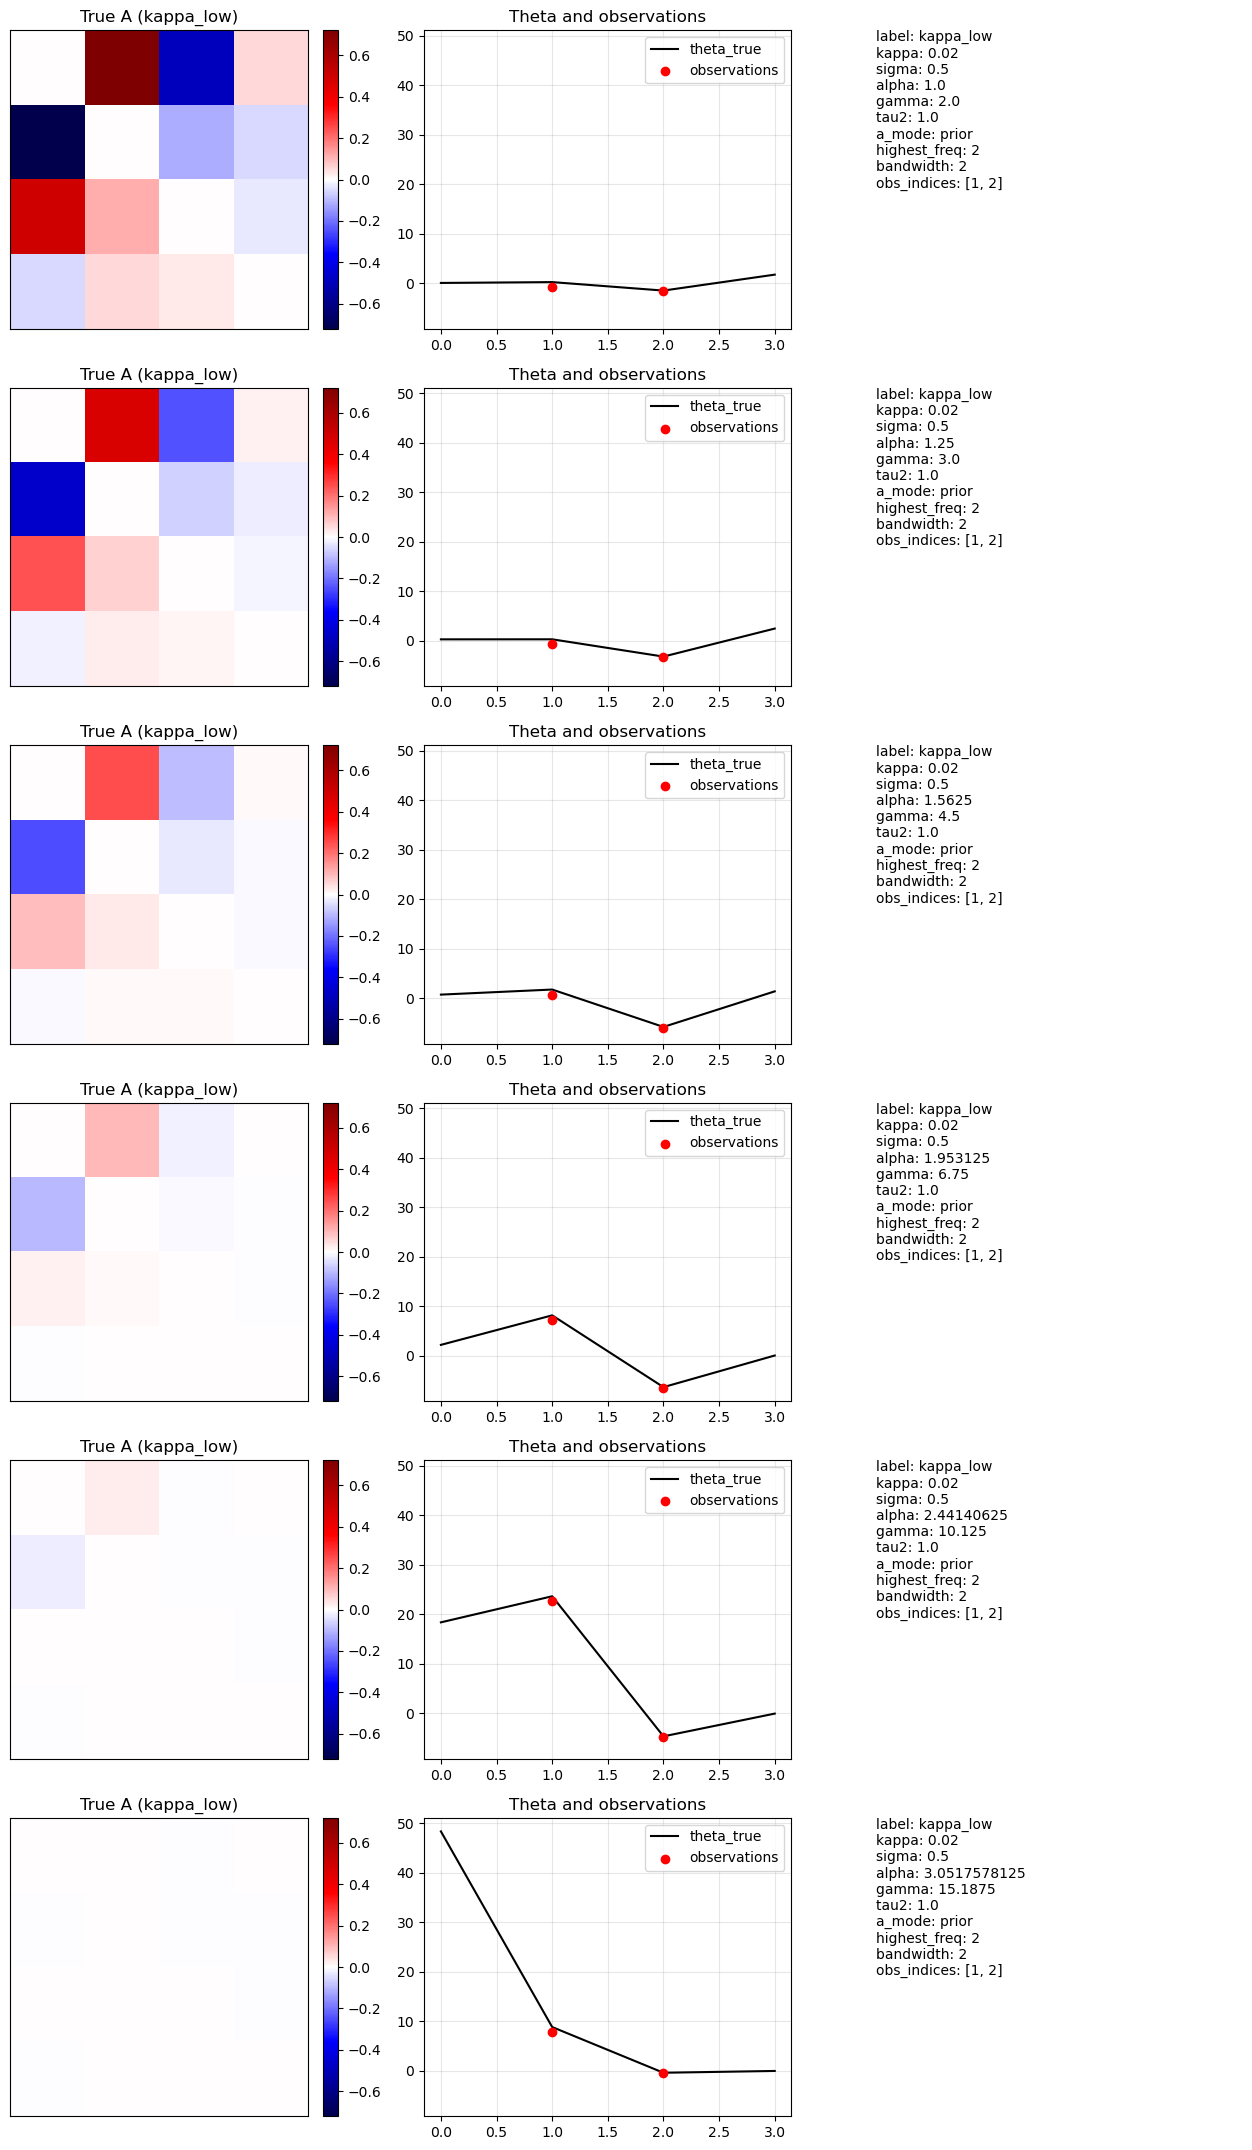

In [10]:
seed_data_sweep = 3

# Visualize true A, simulated data, and hyperparameters for multiple parameter configs.
viz_highest_freq = 2
viz_bandwidth = 2
obs_indices_viz = get_obs_indices(viz_highest_freq, viz_bandwidth, dim)

param_configs = [
    {'label': 'kappa_low', 'kappa': 0.05, 'alpha': 2.0, 'gamma': 3.0},
    {'label': 'base', 'kappa': kappa, 'alpha': 2.0, 'gamma': 3.0},
    {'label': 'kappa_high', 'kappa': 0.2, 'alpha': 2.0, 'gamma': 3.0},
    {'label': 'alpha_low', 'kappa': kappa, 'alpha': 1.0, 'gamma': 3.0},
    {'label': 'alpha_high', 'kappa': kappa, 'alpha': 3.0, 'gamma': 3.0},
    {'label': 'gamma_low', 'kappa': kappa, 'alpha': 2.0, 'gamma': 2.0},
    {'label': 'gamma_high', 'kappa': kappa, 'alpha': 2.0, 'gamma': 4.0},
]
k_factor = 5
factor_alpha = 1.25
factor_gamma = 1.5
param_configs = [
    # # diffusivity
    # {'label': 'kappa_low', 'kappa': kappa, 'alpha': 1.0*factor_alpha, 'gamma': 2.0*factor_gamma},
    # {'label': 'kappa_low', 'kappa': kappa*2, 'alpha': 1.0*factor_alpha, 'gamma': 2.0*factor_gamma},
    # {'label': 'kappa_low', 'kappa': kappa*3, 'alpha': 1.0*factor_alpha, 'gamma': 2.0*factor_gamma},
    # {'label': 'kappa_low', 'kappa': kappa*4, 'alpha': 1.0*factor_alpha, 'gamma': 2.0*factor_gamma},
    # {'label': 'kappa_low', 'kappa': kappa*5, 'alpha': 1.0*factor_alpha, 'gamma': 2.0*factor_gamma},
    # {'label': 'kappa_low', 'kappa': kappa*6, 'alpha': 1.0*factor_alpha, 'gamma': 2.0*factor_gamma},
    # # alpha
    # {'label': 'kappa_low', 'kappa': kappa*2, 'alpha': 1.0, 'gamma': 2.0},
    # {'label': 'kappa_low', 'kappa': kappa*2, 'alpha': 1.0*factor_alpha, 'gamma': 2.0},
    # {'label': 'kappa_low', 'kappa': kappa*2, 'alpha': 1.0*factor_alpha**2, 'gamma': 2.0},
    # {'label': 'kappa_low', 'kappa': kappa*2, 'alpha': 1.0*factor_alpha**3, 'gamma': 2.0},
    # {'label': 'kappa_low', 'kappa': kappa*2, 'alpha': 1.0*factor_alpha**4, 'gamma': 2.0},
    # {'label': 'kappa_low', 'kappa': kappa*2, 'alpha': 1.0*factor_alpha**5, 'gamma': 2.0},
    # # gamma
    # {'label': 'kappa_low', 'kappa': kappa*2, 'alpha': 1.0, 'gamma': 2.0},
    # {'label': 'kappa_low', 'kappa': kappa*2, 'alpha': 1.0, 'gamma': 2.0*factor_gamma},
    # {'label': 'kappa_low', 'kappa': kappa*2, 'alpha': 1.0, 'gamma': 2.0*factor_gamma**2},
    # {'label': 'kappa_low', 'kappa': kappa*2, 'alpha': 1.0, 'gamma': 2.0*factor_gamma**3},
    # {'label': 'kappa_low', 'kappa': kappa*2, 'alpha': 1.0, 'gamma': 2.0*factor_gamma**4},
    # {'label': 'kappa_low', 'kappa': kappa*2, 'alpha': 1.0, 'gamma': 2.0*factor_gamma**5},
    # alpha and gamma
    {'label': 'kappa_low', 'kappa': kappa*2, 'alpha': 1.0, 'gamma': 2.0},
    {'label': 'kappa_low', 'kappa': kappa*2, 'alpha': 1.0*factor_alpha, 'gamma': 2.0*factor_gamma},
    {'label': 'kappa_low', 'kappa': kappa*2, 'alpha': 1.0*factor_alpha**2, 'gamma': 2.0*factor_gamma**2},
    {'label': 'kappa_low', 'kappa': kappa*2, 'alpha': 1.0*factor_alpha**3, 'gamma': 2.0*factor_gamma**3},
    {'label': 'kappa_low', 'kappa': kappa*2, 'alpha': 1.0*factor_alpha**4, 'gamma': 2.0*factor_gamma**4},
    {'label': 'kappa_low', 'kappa': kappa*2, 'alpha': 1.0*factor_alpha**5, 'gamma': 2.0*factor_gamma**5},
]
param_configs = sorted(param_configs, key=lambda cfg: cfg['kappa'])

data_by_config = []
max_abs_A = 0.0
for cfg in param_configs:
    data_viz = generate_advection_diffusion_data(
        dim=dim,
        kappa=cfg['kappa'],
        sigma=sigma,
        obs_indices=obs_indices_viz,
        alpha=cfg['alpha'],
        gamma=cfg['gamma'],
        tau2=tau2,
        a_mode='prior' if use_prior_A else a_mode,
        seed=seed_data_sweep,
    )
    A_true = data_viz['A_true']
    print(f"A_true=\n{A_true}")
    if A_true is None:
        A_true = skew_from_params(dim, data_viz['a_true'])
    max_abs_A = max(max_abs_A, float(np.max(np.abs(A_true))))
    data_by_config.append((cfg, data_viz, A_true))

n_rows = len(data_by_config)
fig, axes = plt.subplots(n_rows, 3, figsize=(13, 3.6 * n_rows), sharey='col')
if n_rows == 1:
    axes = np.array([axes])

for row_idx, (cfg, data_viz, A_true) in enumerate(data_by_config):
    hyperparams = {
        'label': cfg['label'],
        'kappa': cfg['kappa'],
        'sigma': sigma,
        'alpha': cfg['alpha'],
        'gamma': cfg['gamma'],
        'tau2': tau2,
        'a_mode': 'prior' if use_prior_A else a_mode,
        'highest_freq': viz_highest_freq,
        'bandwidth': viz_bandwidth,
        'obs_indices': obs_indices_viz.tolist(),
    }

    ax_A = axes[row_idx, 0]
    ax_theta = axes[row_idx, 1]
    ax_text = axes[row_idx, 2]

    im = ax_A.imshow(
        A_true,
        cmap='seismic',
        vmin=-max_abs_A,
        vmax=max_abs_A,
    )
    ax_A.set_title(f"True A ({cfg['label']})")
    ax_A.set_xticks([])
    ax_A.set_yticks([])
    fig.colorbar(im, ax=ax_A, fraction=0.046, pad=0.04)

    ax_theta.plot(data_viz['theta_true'], color='black', label='theta_true')
    ax_theta.scatter(obs_indices_viz, data_viz['y'], color='red', label='observations', zorder=3)
    ax_theta.set_title('Theta and observations')
    ax_theta.grid(alpha=0.3)
    ax_theta.legend(loc='best')

    ax_text.axis('off')
    text_lines = [f"{k}: {v}" for k, v in hyperparams.items()]
    ax_text.text(0.0, 1.0, '\n'.join(text_lines), va='top')

plt.tight_layout()

a_true: [ 0.72157388 -0.49183796  0.05226236 -0.11589549 -0.05334523 -0.03111877], prior_diag: [0.125      0.03703704 0.015625   0.04166667 0.01388889 0.02083333], a_true.shape: (6,), prior_diag.shape: (6,)
a_true: [-0.23044297 -0.03362436  0.2079655   0.13454797 -0.19344053 -0.00075103], prior_diag: [0.125      0.03703704 0.015625   0.04166667 0.01388889 0.02083333], a_true.shape: (6,), prior_diag.shape: (6,)
a_true: [-0.28352557 -0.25487301 -0.0310452   0.08582302  0.13388437  0.01583475], prior_diag: [0.125      0.03703704 0.015625   0.04166667 0.01388889 0.02083333], a_true.shape: (6,), prior_diag.shape: (6,)
a_true: [ 0.37233265  0.34188591 -0.31916148 -0.028162    0.11946798  0.19516486], prior_diag: [0.125      0.03703704 0.015625   0.04166667 0.01388889 0.02083333], a_true.shape: (6,), prior_diag.shape: (6,)
a_true: [ 0.00043492  0.05749361 -0.03426723 -0.1817913  -0.05358347 -0.14313185], prior_diag: [0.125      0.03703704 0.015625   0.04166667 0.01388889 0.02083333], a_true.s

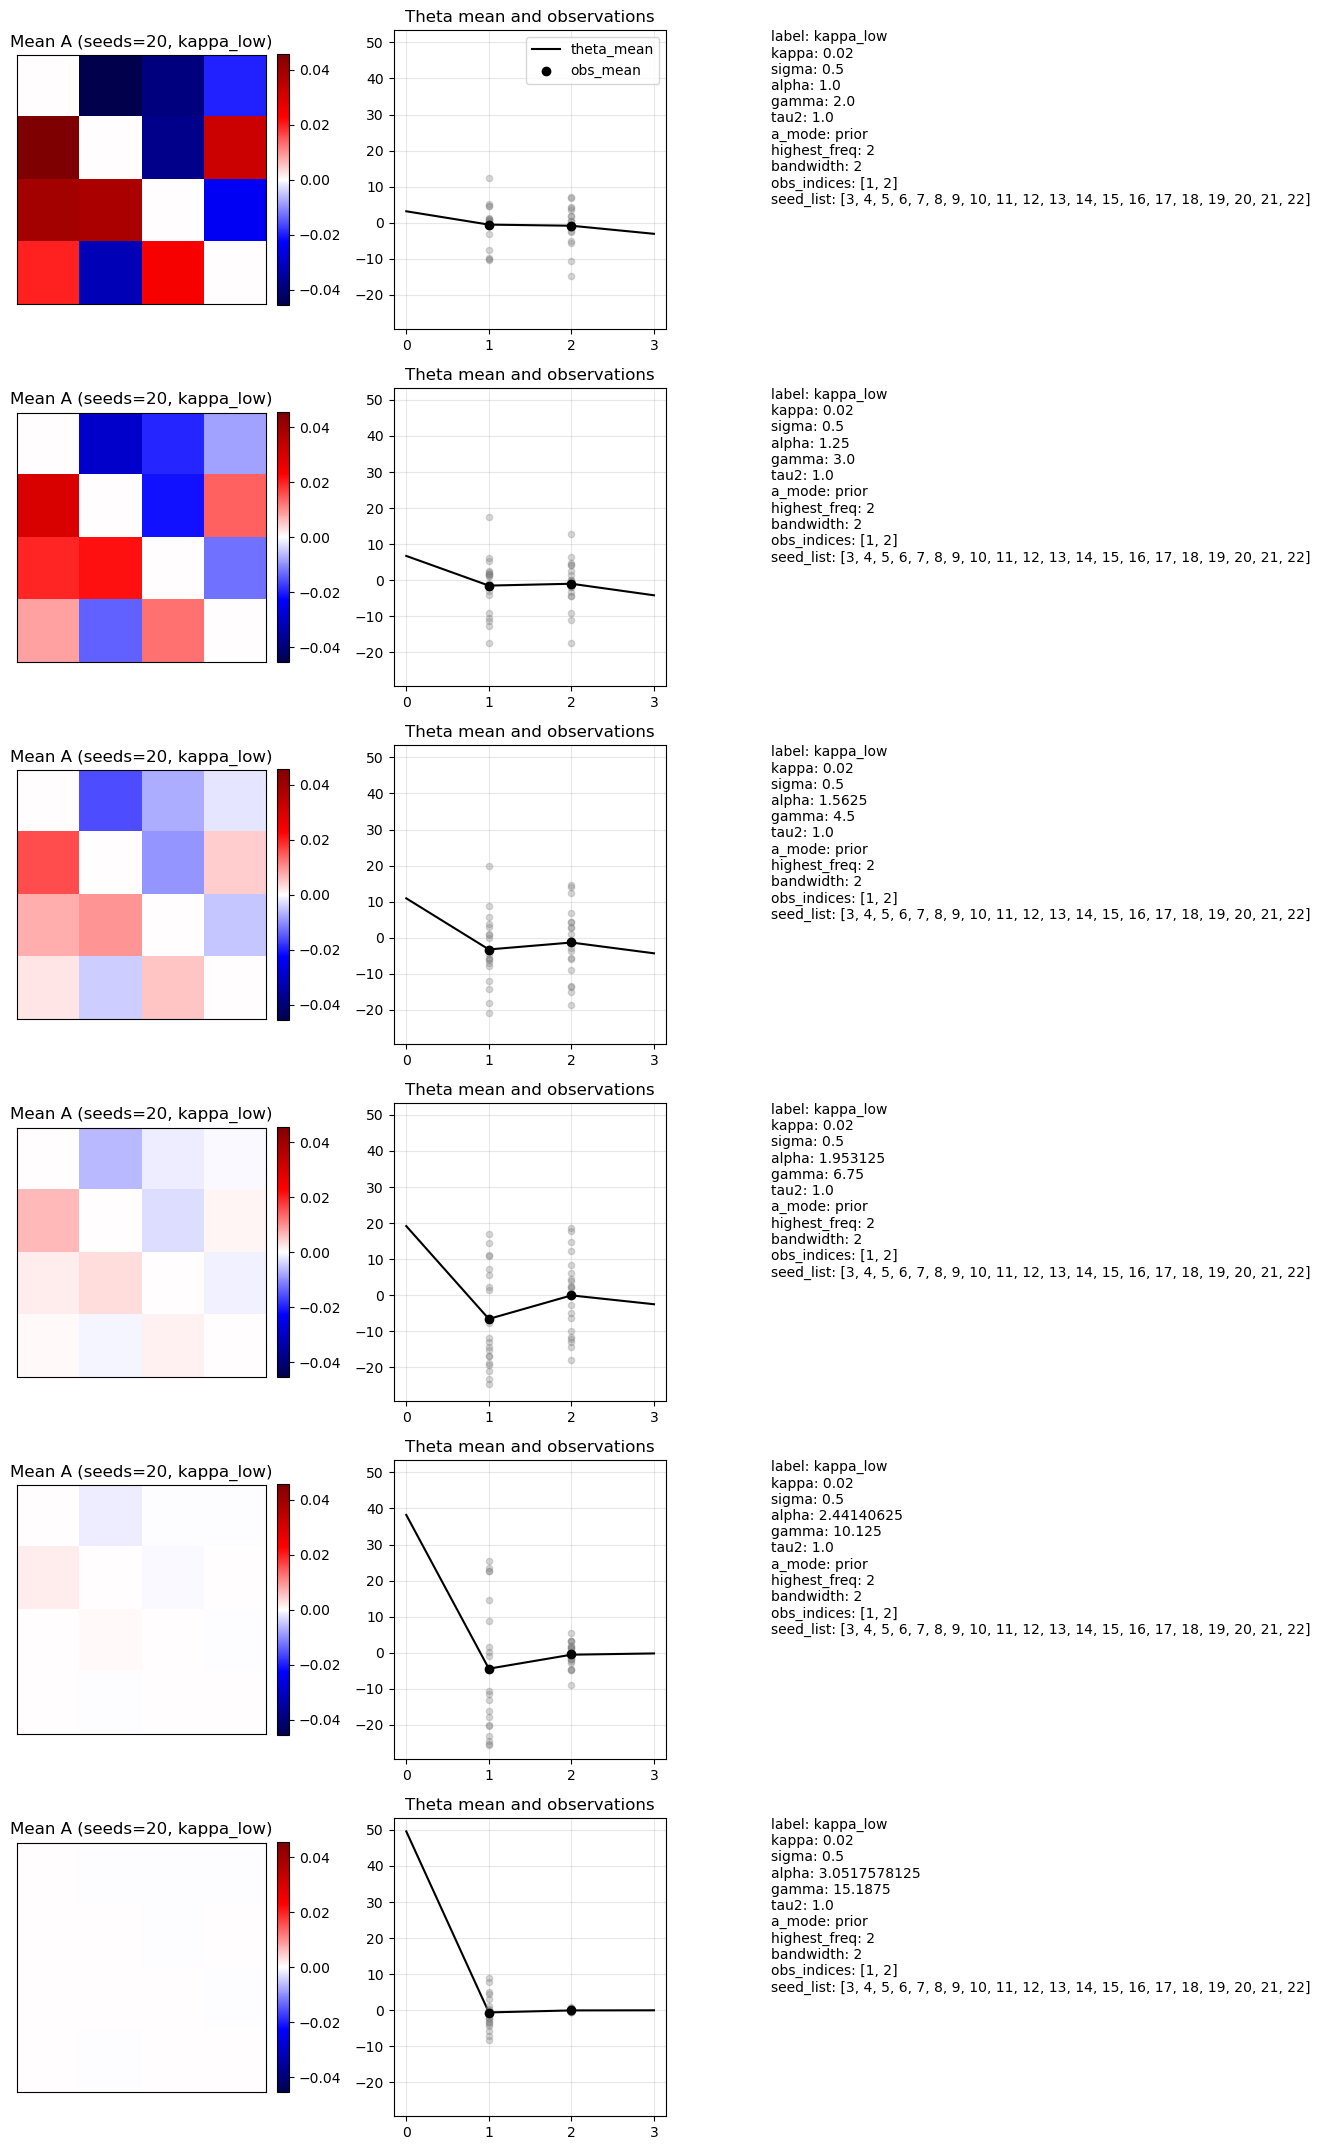

In [11]:
# Repeat hyperparameter visualization using multiple seeds.
num_seeds = 20
seed_list = list(range(seed_data_sweep, seed_data_sweep + num_seeds))

data_by_config_multi = []
max_abs_A_mean = 0.0
for cfg in param_configs:
    A_trues = []
    y_list = []
    theta_list = []
    for seed in seed_list:
        data_viz = generate_advection_diffusion_data(
            dim=dim,
            kappa=cfg['kappa'],
            sigma=sigma,
            obs_indices=obs_indices_viz,
            alpha=cfg['alpha'],
            gamma=cfg['gamma'],
            tau2=tau2,
            a_mode='prior' if use_prior_A else a_mode,
            seed=seed,
        )
        A_true = data_viz['A_true']
        if A_true is None:
            A_true = skew_from_params(dim, data_viz['a_true'])
        A_trues.append(A_true)
        y_list.append(data_viz['y'])
        theta_list.append(data_viz['theta_true'])
    A_trues = np.stack(A_trues, axis=0)
    y_stack = np.stack(y_list, axis=0)
    theta_stack = np.stack(theta_list, axis=0)

    A_mean = A_trues.mean(axis=0)
    y_mean = y_stack.mean(axis=0)
    theta_mean = theta_stack.mean(axis=0)
    max_abs_A_mean = max(max_abs_A_mean, float(np.max(np.abs(A_mean))))
    data_by_config_multi.append((cfg, A_mean, y_stack, y_mean, theta_mean))

n_rows = len(data_by_config_multi)
fig, axes = plt.subplots(n_rows, 3, figsize=(13, 3.6 * n_rows), sharey='col')
if n_rows == 1:
    axes = np.array([axes])

for row_idx, (cfg, A_mean, y_stack, y_mean, theta_mean) in enumerate(data_by_config_multi):
    hyperparams = {
        'label': cfg['label'],
        'kappa': cfg['kappa'],
        'sigma': sigma,
        'alpha': cfg['alpha'],
        'gamma': cfg['gamma'],
        'tau2': tau2,
        'a_mode': 'prior' if use_prior_A else a_mode,
        'highest_freq': viz_highest_freq,
        'bandwidth': viz_bandwidth,
        'obs_indices': obs_indices_viz.tolist(),
        'seed_list': seed_list,
    }

    ax_A = axes[row_idx, 0]
    ax_theta = axes[row_idx, 1]
    ax_text = axes[row_idx, 2]

    im = ax_A.imshow(
        A_mean,
        cmap='seismic',
        vmin=-max_abs_A_mean,
        vmax=max_abs_A_mean,
    )
    ax_A.set_title(f"Mean A (seeds={num_seeds}, {cfg['label']})")
    ax_A.set_xticks([])
    ax_A.set_yticks([])
    fig.colorbar(im, ax=ax_A, fraction=0.046, pad=0.04)

    ax_theta.plot(theta_mean, color='black', label='theta_mean')
    for y_obs in y_stack:
        ax_theta.scatter(
            obs_indices_viz,
            y_obs,
            color='gray',
            alpha=0.3,
            s=20,
            zorder=2,
        )
    ax_theta.scatter(
        obs_indices_viz,
        y_mean,
        color='black',
        label='obs_mean',
        zorder=3,
    )
    ax_theta.set_title('Theta mean and observations')
    ax_theta.grid(alpha=0.3)
    if row_idx == 0:
        ax_theta.legend(loc='best')

    ax_text.axis('off')
    text_lines = [f"{k}: {v}" for k, v in hyperparams.items()]
    ax_text.text(0.0, 1.0, '\n'.join(text_lines), va='top')

plt.tight_layout()

## Hyperparameter Experiments with Multi-Seed Means
Repeat the hyperparameter visualization using multiple seeds and plot mean fields/observations.

In [24]:
# Posterior pair-wise plots
import importlib
import multiproposal.plotting.diagnostics
importlib.reload(multiproposal.plotting.diagnostics)
from multiproposal.plotting.diagnostics import write_csv, plot_timeseries, make_hist_grid_comps
panel_comps = np.arange(num_params)  # Plot all components in the grid
labels_chains = [f"hf={highest_freq}, bw={bandwidth}" for cfg in obs_configs for highest_freq, bandwidth in [(cfg['highest_freq'], cfg['bandwidth'])]]
chains_plot = {label: chains_by_label[label] for label in labels_chains}
label_map = dict(zip(comps, get_component_labels(dim, comps)))
covariances = {}
kappas = {}
alphas = {}
gammas = {}
tau2s = {}
sigmas = {}
for config in obs_configs:
    highest_freq = config['highest_freq']
    bandwidth = config['bandwidth']
    data, problem, obs_indices = build_problem_for_obs_config(
        highest_freq, bandwidth, use_prior_A=use_prior_A
    )
    lab = f"hf={highest_freq}, bw={bandwidth}"
    covariances[lab] = data['prior_diag']
    kappas[lab] = data['kappa']
    alphas[lab] = data['alpha']
    gammas[lab] = data['gamma']
    tau2s[lab] = data['tau2']
    sigmas[lab] = data['sigma']

plot_title = "Posterior Marginals and Pairwise Densities"
font_size = 12

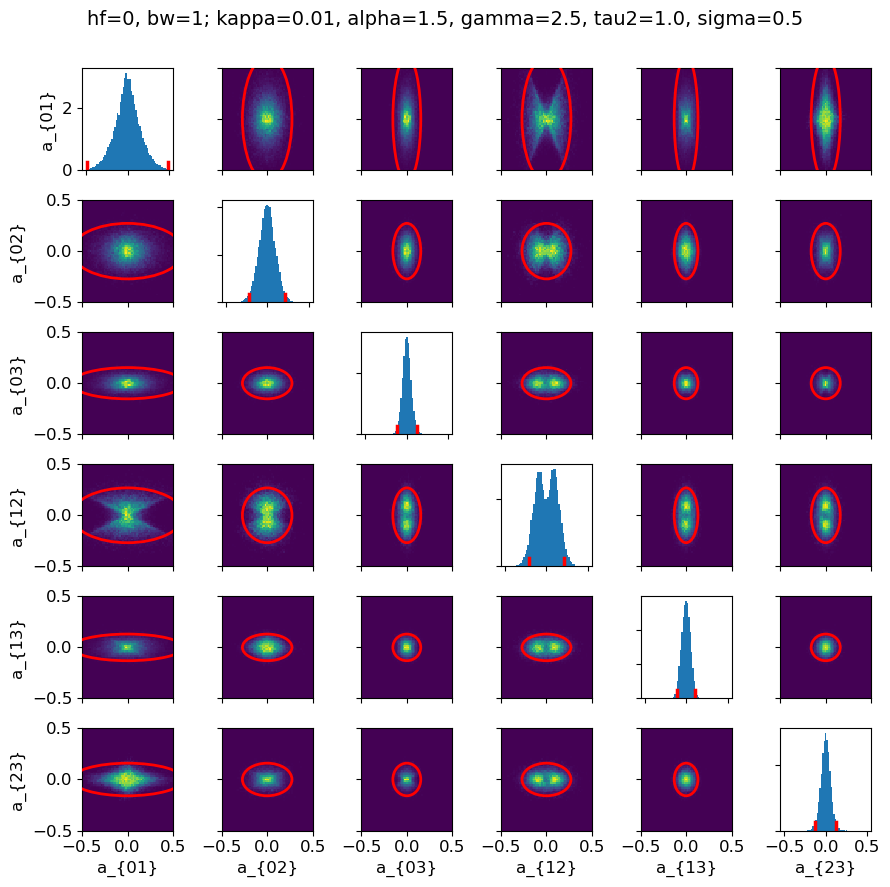

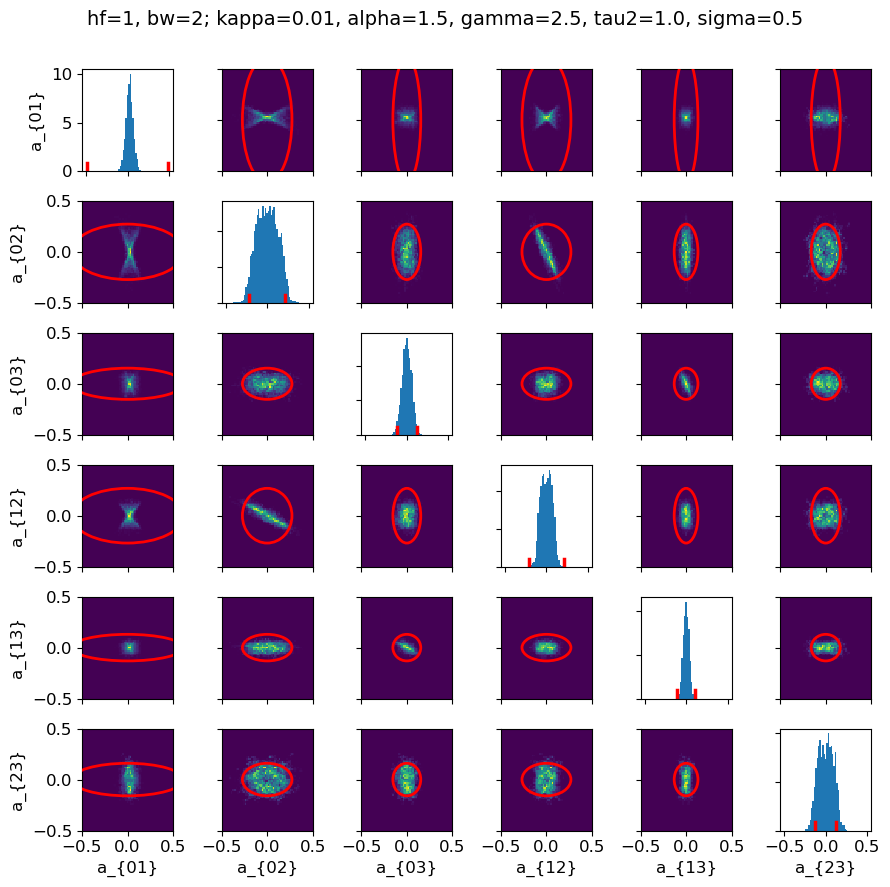

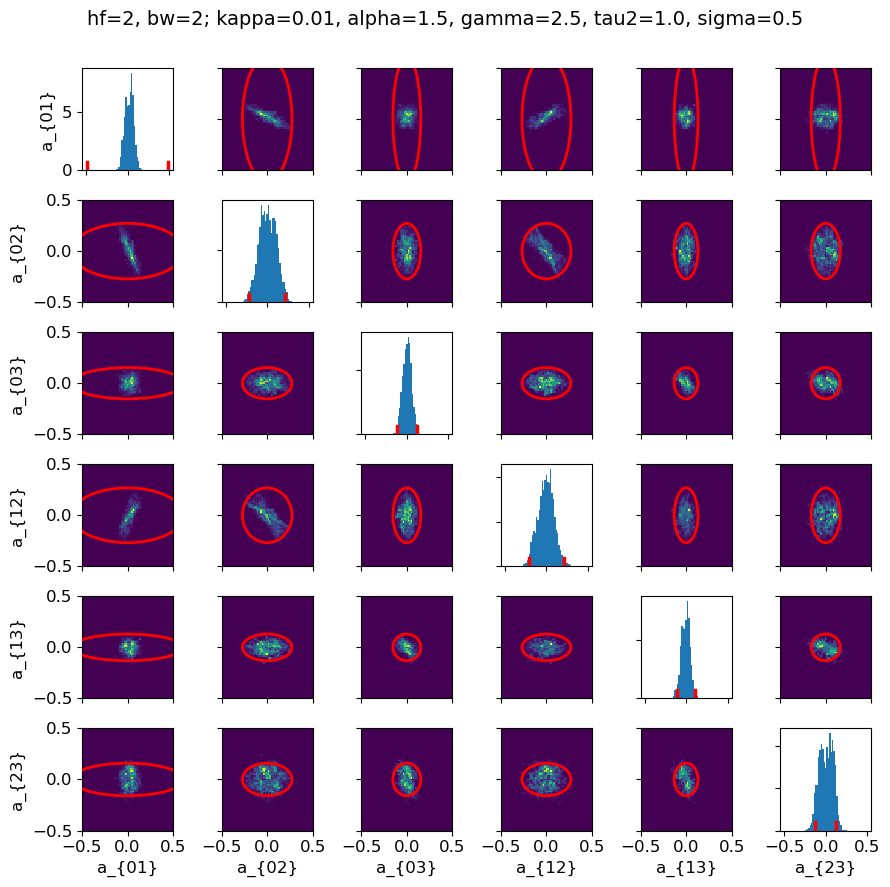

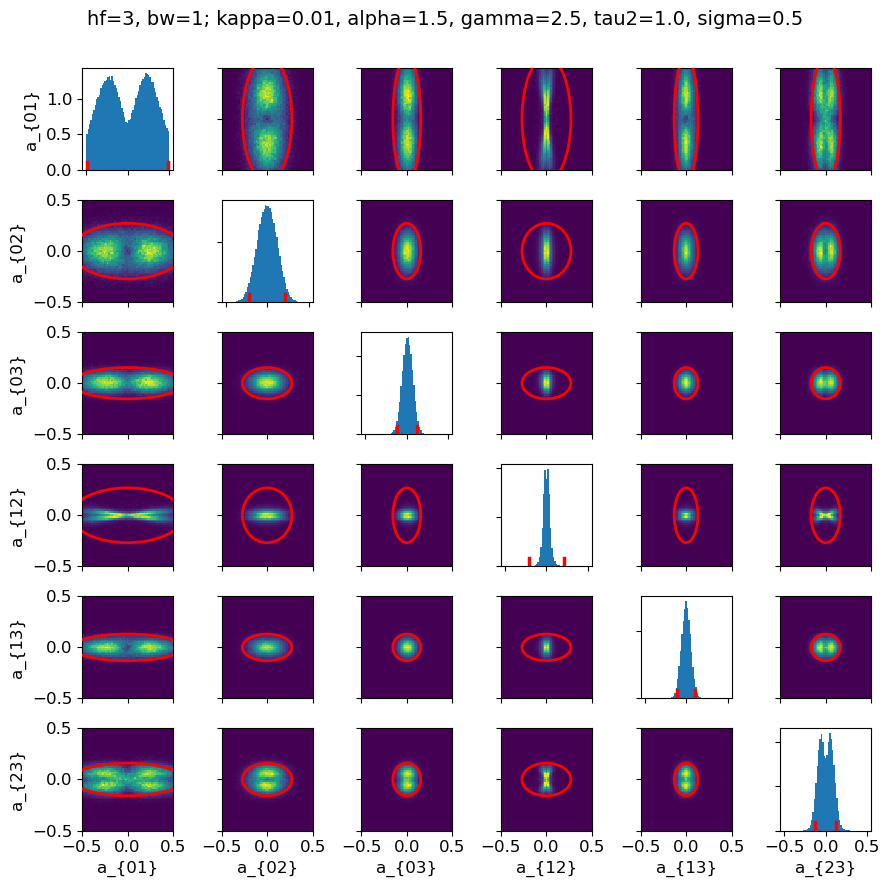

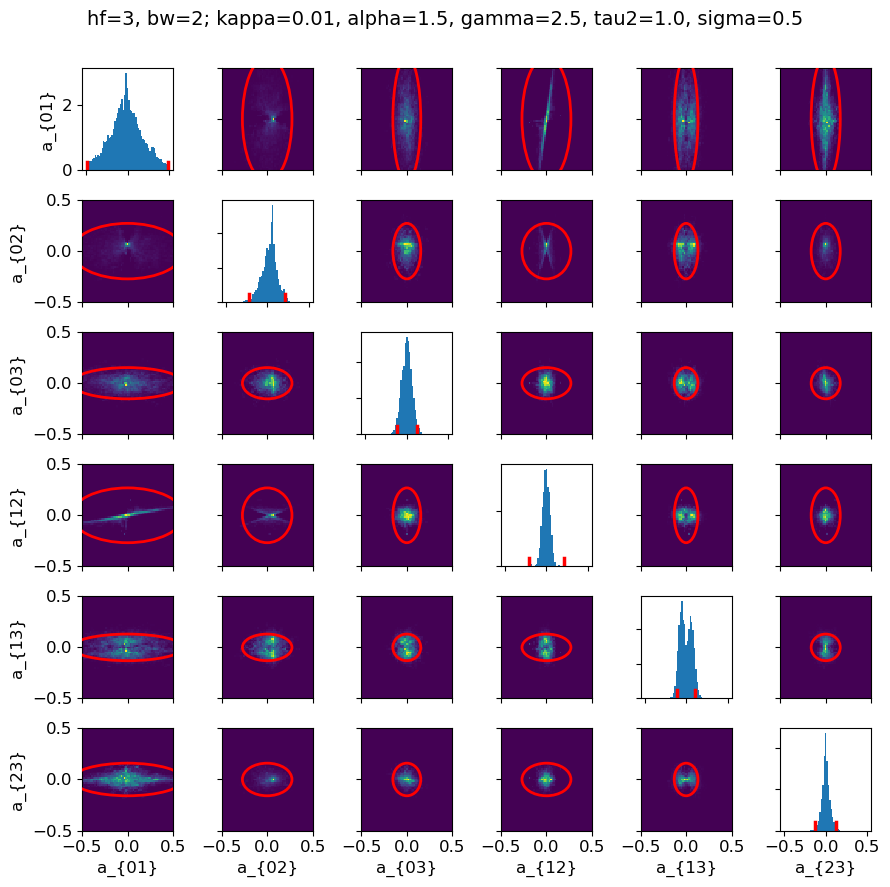

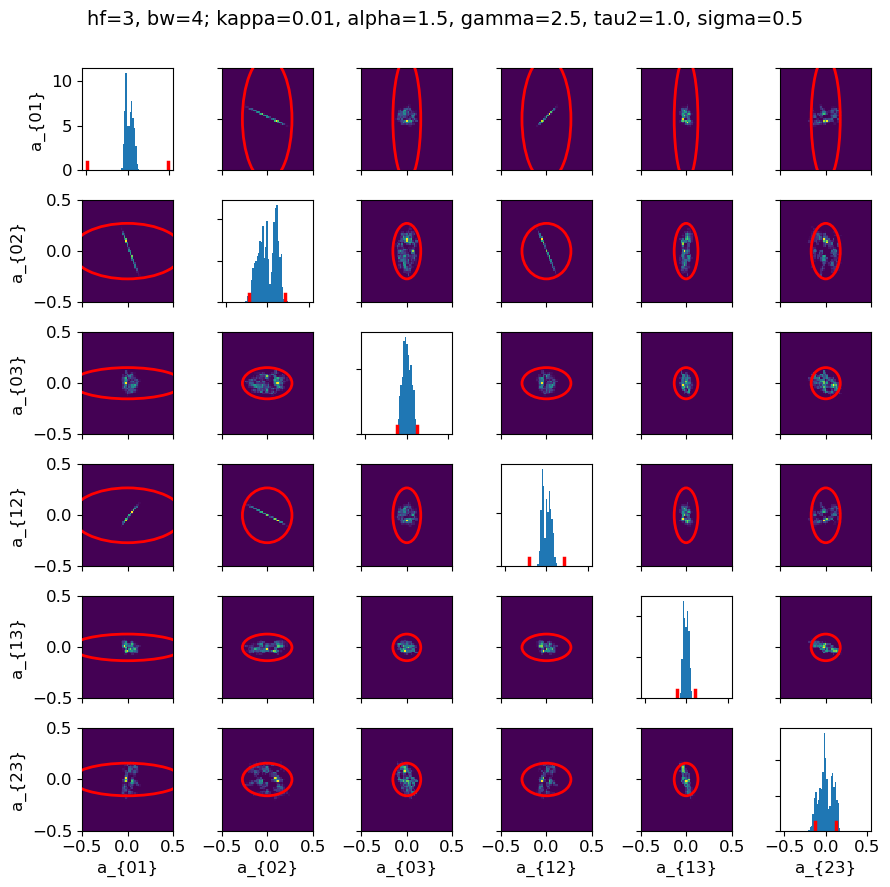

In [28]:

for label, est_chain in chains_plot.items():
    
    
    R = sigmas[label]
    dr = sigmas[label] / 30
    fig = make_hist_grid_comps(
        R,
        dr,
        est_chain,
        panel_comps,
        None,
        C=np.diag(covariances[label]),
        beta=0.95,
        hide_plot=False,
        label_map=label_map,
        font_size=font_size,
        title=f"{label}; kappa={kappas[label]}, alpha={alphas[label]}, gamma={gammas[label]}, tau2={tau2s[label]}, sigma={sigmas[label]}",
        figsize=(9, 9)
    )
    # fig.savefig('post_marginals_pairwise_dens_testing1.pdf', dpi=600)